# Football clip analysis with Claude (video first, tracking data second)
1. Extract frames from the clip
2. **Estimate the price** for every model
3. Confirm, then run the analysis

In [1]:
%pip install -q anthropic opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os, math, base64, getpass
import cv2
import anthropic
from IPython.display import display, Image, Markdown

# ---------- CONFIG ----------
CLIP_PATH = r"C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\new\press\buildup_output\clips_buildup\lost_under_pressure\b069_ATM_19-24.mp4"
TRACKING_PATH = r"C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\new\press\buildup_output\prompts\lost_under_pressure\b040_ATM_11-54.txt"          # None -> looks for <clip name>.txt next to the clip
FPS_TO_SEND = 4               # frames per second sent to Claude (try 2, 4, 5)
WIDTH = 960                   # frames are resized to this width
MODEL = "claude-sonnet-5-5"   # model used for the real run
EXPECTED_OUTPUT_TOKENS = 700  # ~350 words (+ margin)
MAX_FRAMES = 100

# USD per million tokens: (input, output). Haiku 5.5 costs more for prompts > 100k tokens.
PRICES = {
    "claude-haiku-5-5":  (0.10, 0.50),
    "claude-sonnet-5-5": (2.0, 10.0),
    "claude-opus-5-5":   (4.0, 20.0),
    "claude-fable-5-1":  (10.0, 50.0),
}
HAIKU_LONG = (0.50, 2.50)

if "ANTHROPIC_API_KEY" not in os.environ:
    os.environ["ANTHROPIC_API_KEY"] = getpass.getpass("Anthropic API key: ")
client = anthropic.Anthropic()

Source 25.0 fps | sending every 6 frames -> 45 frames of 960x540


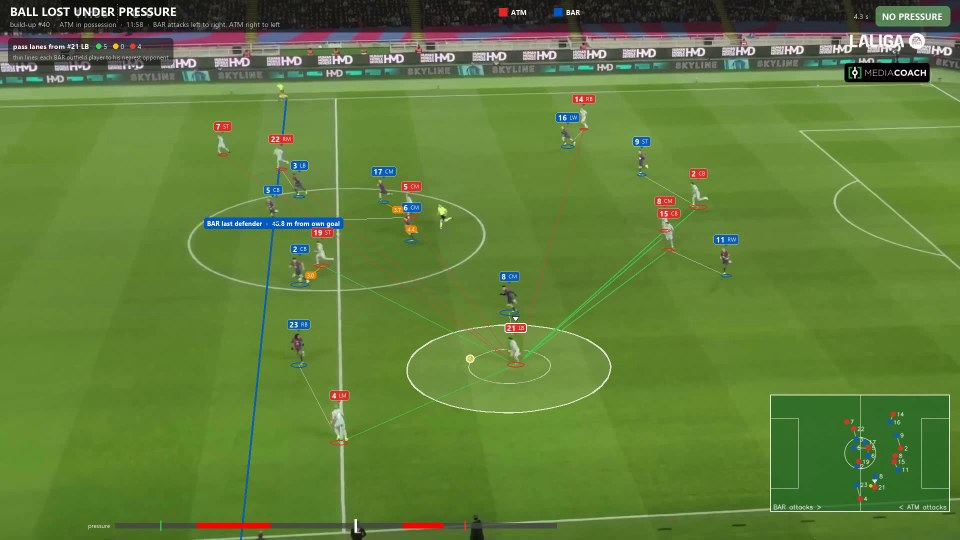

In [3]:
def fmt(t):
    return f"{int(t // 60):02d}:{t % 60:04.1f}"

def extract_frames(path, fps, width, max_frames=MAX_FRAMES):
    cap = cv2.VideoCapture(path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video: {path}")
    src_fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    step = max(1, round(src_fps / fps))
    frames, idx = [], 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if idx % step == 0:
            h, w = frame.shape[:2]
            if w > width:
                frame = cv2.resize(frame, (width, round(h * width / w)))
            ok2, buf = cv2.imencode(".jpg", frame, [cv2.IMWRITE_JPEG_QUALITY, 88])
            if ok2:
                frames.append({"t": idx / src_fps, "b64": base64.b64encode(buf).decode(),
                               "w": frame.shape[1], "h": frame.shape[0], "jpg": buf.tobytes()})
        idx += 1
    cap.release()
    if len(frames) > max_frames:
        frames = [frames[round(i * (len(frames) - 1) / (max_frames - 1))] for i in range(max_frames)]
    print(f"Source {src_fps:.1f} fps | sending every {step} frames -> {len(frames)} frames "
          f"of {frames[0]['w']}x{frames[0]['h']}")
    return frames

frames = extract_frames(CLIP_PATH, FPS_TO_SEND, WIDTH)
display(Image(data=frames[len(frames)//2]["jpg"]))   # preview of the middle frame

In [4]:
PREFACE = """You are a football tactical analyst. The images above are frames sampled from ONE short clip,
each labelled with its CLIP time (mm:ss.s from the start of the video).

PRIORITY OF EVIDENCE
1. The VIDEO FRAMES are the primary evidence. Base your analysis first on what you can actually SEE:
   body shape, pressing angles, who covers the passing lanes, distances between players, the carrier's
   isolation, how the block is set, the moment and cause of the turnover.
2. The TRACKING DATA below is supporting evidence. Use it to confirm or quantify what you see
   (distances, number of pressers, timing) and to get player names + shirt numbers.
3. If the video and the data disagree, say so and trust the video. Frames are sampled, so very fast
   actions between frames may be missed - say so if that limits a claim.
4. Never invent numbers. A number must come from the data; a visual claim must come from a frame
   (cite its clip time).

The original task, rules and output format follow."""

tracking_path = TRACKING_PATH or os.path.splitext(CLIP_PATH)[0] + ".txt"
if os.path.exists(tracking_path):
    tracking = open(tracking_path, encoding="utf-8").read()
    print("Tracking data loaded:", tracking_path)
else:
    tracking = ""
    print("No tracking file found -> video-only analysis:", tracking_path)

final_text = PREFACE + ("\n\n" + tracking if tracking else
                        "\n\nNo tracking data is available for this clip: analyse the video only.")

content = []
for f in frames:
    content.append({"type": "text", "text": f"Frame at clip time {fmt(f['t'])}:"})
    content.append({"type": "image", "source": {"type": "base64", "media_type": "image/jpeg", "data": f["b64"]}})
content.append({"type": "text", "text": final_text})
messages = [{"role": "user", "content": content}]

Tracking data loaded: C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\new\press\buildup_output\prompts\lost_under_pressure\b040_ATM_11-54.txt


In [5]:
# ---------- PRICE ESTIMATE (nothing is sent to the model here) ----------
image_tokens = sum(math.ceil(f["w"] / 28) * math.ceil(f["h"] / 28) for f in frames)
label_tokens = len(frames) * 10
text_tokens  = int(len(final_text) / 3)            # conservative chars-per-token
est_input    = image_tokens + label_tokens + text_tokens

# Optional exact count (free endpoint). Falls back to the estimate if unavailable.
try:
    exact = client.messages.count_tokens(model=MODEL, messages=messages).input_tokens
    print(f"Exact input tokens for {MODEL}: {exact:,} (formula estimate was {est_input:,})")
    est_input = exact
except Exception as e:
    print(f"(count_tokens unavailable, using formula estimate) {type(e).__name__}")

print(f"\nFrames: {len(frames)} | image tokens ~{image_tokens:,} | text tokens ~{text_tokens:,}")
print(f"TOTAL INPUT ~{est_input:,} tokens | OUTPUT assumed {EXPECTED_OUTPUT_TOKENS} tokens\n")

print(f"{'Model':<20}{'Per clip':>12}{'Batch (-50%)':>15}{'x 100 clips':>14}")
for m, (pin, pout) in PRICES.items():
    if m == "claude-haiku-5-5" and est_input > 100_000:
        pin, pout = HAIKU_LONG
    c = est_input * pin / 1e6 + EXPECTED_OUTPUT_TOKENS * pout / 1e6
    mark = "  <- selected" if m == MODEL else ""
    print(f"{m:<20}${c:>10.4f}${c/2:>14.4f}${c*100:>13.2f}{mark}")

Exact input tokens for claude-sonnet-5-5: 36,103 (formula estimate was 34,810)

Frames: 45 | image tokens ~31,500 | text tokens ~2,860
TOTAL INPUT ~36,103 tokens | OUTPUT assumed 700 tokens

Model                   Per clip   Batch (-50%)   x 100 clips
claude-haiku-5-5    $    0.0040$        0.0020$         0.40
claude-sonnet-5-5   $    0.0792$        0.0396$         7.92  <- selected
claude-opus-5-5     $    0.1584$        0.0792$        15.84
claude-fable-5-1    $    0.3960$        0.1980$        39.60


In [8]:
# ---------- CONFIRM, THEN RUN ----------
answer = input(f"Proceed with {MODEL}? (y/n): ").strip().lower()
if answer != "y":
    raise SystemExit("Cancelled - nothing was sent.")

resp = client.messages.create(
    model=MODEL,
    max_tokens=4000,                  # room for thinking + the 350-word answer
    # thinking={"type": "disabled"},  # optional: uncomment for a fixed, cheaper cost
    messages=messages,
)

# keep only the text blocks (skip thinking blocks)
text = "".join(b.text for b in resp.content if b.type == "text")
display(Markdown(text))

pin, pout = PRICES[MODEL]
u = resp.usage
if MODEL == "claude-haiku-5-5" and u.input_tokens > 100_000:
    pin, pout = HAIKU_LONG
cost = u.input_tokens * pin / 1e6 + u.output_tokens * pout / 1e6
print(f"\nWords: {len(text.split())} | tokens in={u.input_tokens:,} out={u.output_tokens:,} | actual cost ${cost:.4f}")

**1. Verdict**
BAR's pressure worked only at the very end. Max pressers was 1 throughout, and ATM had been unpressed for about 2 s (00:04–00:06). The turnover came from a late chase by Pedri #8 (CM) and a forced pass into a marked teammate, which Cubarsi #2 (CB) intercepted. It was not won by sustained pressure.

**2. Why**
1. **Pass into a covered target (00:06–00:07).** Javi Galan #21 (LB) was alone, with 0 teammates within 10 m. He played the ball toward Alvarez #19 (ST) (4.6 m from his nearest opponent at 00:06). The frames show Cubarsi #2 (CB) goal-side of Alvarez in the same area (00:06.0–00:07.2). Cubarsi #2 (CB) had the ball at 00:07.4 and was credited with the next control 0.0 s after the phase ended. The lane was already shown as contested from 00:06.0.
2. **Late pressure on the carrier (00:06–00:07).** Pedri #8 (CM) pressed for 0.9 s, closing at 5.3 m/s from 2.3 m. Galan #21 (LB) is on the ground by 00:07.2, so he released the ball off-balance. This is the only pressure that mattered.
3. **BAR's line dropped to keep cover (00:01–00:07).** BAR's last defender went from 52.2 m to 33.2 m from their own goal. The block stayed compact around Alvarez #19 (ST) and Simeone #22 (RM), so forward passes met a defender.
4. **Possession side: a better option existed.** At 00:06 Gallagher #4 (LM) was free, 11 m away with the nearest opponent 10.0 m away. Galan #21 (LB) chose the pass into traffic (Alvarez #19, ST) instead.

Earlier pressure failed. At 00:02–00:03 Pedri #8 (CM) closed at 5.1 m/s to 0.1 m. Raphinha #11 (RW) pressed for 0.4 s. Lenglet #15 (CB) still got the ball away. By 00:04 there were 0 pressers and the closest defender was 9.2 m away. Galan #21 (LB) then carried from x=41.7 to 48.3 m with the closest opponent at 7.4 m (00:05) and 5.6 m (00:06).

**Video/data note:** The data lists 5 free options at 00:06, but the video shows the Alvarez #19 (ST) lane was effectively covered, so "free" overstates it. The pass and interception fall between the 0.2 s frames, so I can't see the exact moment of release.

**3. Counterfactual**
At 00:06 Galan #21 (LB) was unpressed (closest opponent 5.6 m). He could have played short to Gallagher #4 (LM), 11 m away and 10 m from his nearest opponent. He could also have kept carrying until Pedri #8 (CM) committed, instead of releasing the pass while Pedri was closing at 5.3 m/s.


Words: 422 | tokens in=36,103 out=2,068 | actual cost $0.0929
